<a href="https://colab.research.google.com/github/cpython-projects/python_da_17_03_26/blob/main/lesson_30.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import plotly.express as px

# LTV (Lifetime Value)

**LTV (Customer Lifetime Value)** — це очікуваний прибуток, який приносить один користувач за весь час взаємодії з продуктом.

LTV показує, скільки компанія заробляє на користувачеві з моменту його першого контакту і до того, як він перестає користуватися продуктом.

### Навіщо LTV потрібен

* Визначати, **скільки можна витрачати на залучення нового користувача** (CAC).
* Порівнювати **канали залучення**: де приходять якісні користувачі з високим LTV.
* Планувати **бізнес-моделі і маркетингові бюджети**.

### Формула базового LTV (спрощена)

$$
LTV = \text{Середній дохід на користувача (ARPU)} \times \text{Середня тривалість життя користувача (в місяцях/тижнях)}
$$

# Retention (утримання користувачів)

**Retention** — це показник того, скільки користувачів повертаються до продукту після першого використання.

Іншими словами, він показує, **наскільки продукт цікавий і корисний для користувача з часом**.

---

### Формула базового retention

Якщо ми рахуємо **по місяцях**:
$$
Retention\ Rate = \frac{\text{Кількість користувачів, які повернулися у місяць N}}{\text{Кількість користувачів, які прийшли у місяць 0}} \times 100%
$$
**Приклад:**

* У січні зареєструвалося 100 користувачів (це наша когорта).
* У лютому 40 з них зробили повторну активність.
* Retention на другий місяць = 40 / 100 × 100% = 40%.

Важливо:

* **Retention відображає лише користувачів когортно**, тобто тих, хто був у когорті певного періоду.
* Метрика завжди **враховує час**, бо ми дивимось на «вік» користувача від моменту першого заходу.

---

### Як виглядає retention на практиці

| Місяць реєстрації | Місяць 0 | Місяць 1 | Місяць 2 |
| ----------------- | -------- | -------- | -------- |
| Січень            | 100%     | 40%      | 25%      |
| Лютий             | 100%     | 50%      | -        |

* Стрічки — це когорти за місяцями першого заходу
* Колонки — «вік» когорт (місяць 0, місяць 1, місяць 2)
* Значення — відсоток користувачів, які залишилися активними

# Когортний аналіз

## Проблема  

Під час аналізу даних ми дуже часто працюємо із середніми показниками: середній дохід, середній retention, середня кількість активних користувачів.
Але середні значення мають одну важливу проблему — вони **приховують динаміку у часі**.

Наприклад, загальний retention може виглядати стабільним, але при цьому:

* нові користувачі утримуються гірше,
* старі когорти поступово «підтягують» середнє,
* маркетингові канали приводять різних за якістю користувачів.

Саме для того, щоб побачити ці відмінності, використовується **когортний аналіз**.

## 2. Що таке когорта

**Когорта** — це група користувачів, об’єднаних **спільною подією** та **моментом часу**, коли ця подія відбулася.

Іншими словами, ми групуємо користувачів не випадково, а за тим, **коли і за яких умов вони вперше з’явилися в системі**.

### Приклади когорт:

* користувачі, які **зареєструвалися в одному місяці**;
* клієнти, які **здійснили першу покупку в один і той самий тиждень**;
* користувачі, які **прийшли з одного маркетингового каналу в певний період часу**.

Важливо розуміти, що після формування когорти **користувач залишається в ній назавжди**.
Когорта — це точка відліку для подальшого аналізу поведінки.

## 3. Навіщо потрібен когортний аналіз

Когортний аналіз дозволяє відповісти на ключові бізнес-питання, на які не можуть відповісти середні метрики.

### 3.1 Показує утримання користувачів

Ми можемо побачити:

* як довго користувачі залишаються активними;
* у який момент відбувається найбільший відтік;
* чи покращується retention у нових когорт.

### 3.2 Оцінює якість залучення

Два канали можуть приводити однакову кількість користувачів, але:

* один канал дає довгострокових клієнтів;
* інший — користувачів, які зникають через місяць.

Когортний аналіз чітко показує цю різницю.

### 3.3 Порівнює «старих» і «нових» користувачів

Ми можемо відповісти на питання:

* чи став продукт кращим з часом;
* чи погіршився досвід нових користувачів;
* як змінюється поведінка клієнтів у різних періодах.

### 3.4 Допомагає знаходити деградацію продукту або зростання LTV

Якщо:

* retention падає у нових когорт — це сигнал проблеми;
* LTV зростає від когорти до когорти — це ознака покращення продукту або маркетингу.

---

## Ключова ідея

📌 **Середні метрики приховують правду.
Когортний аналіз цю правду розкриває.**

Саме тому когортний аналіз є базовим інструментом для:

* продуктового аналітика,
* маркетингового аналітика,
* бізнес-аналітика.

# Як пов’язані LTV, retention і когорти

* Retention показує **скільки користувачів повертається з часом**
* LTV показує **скільки грошей приносить кожен користувач за весь період**
* Когортний аналіз дозволяє **зрозуміти, як LTV і retention змінюються по когортам і каналам залучення**

# Приклад. e-commerce

In [13]:
df = pd.read_csv('https://raw.githubusercontent.com/cpython-projects/da_1709/refs/heads/main/online_retail_II.csv')

In [14]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
df.shape

(1067371, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


## Легенда

| Колонка     | Опис             |
| ----------- | ---------------- |
| Invoice     | Номер замовлення |
| StockCode   | Код товару       |
| Description | Назва товару     |
| Quantity    | Кількість        |
| InvoiceDate | Дата покупки     |
| Price       | Ціна за одиницю  |
| Customer ID | ID клієнта       |
| Country     | Країна           |

* кожен рядок — **позиція в чеку**, не покупка
* одна покупка = один `Invoice`, але багато рядків

Фактично це **лог транзакцій**.

---

## Бізнес-задача

> Бізнес хоче зрозуміти:
> **чи повертаються клієнти після першої покупки і як довго вони приносять дохід?**

Конкретно:

* Який відсоток клієнтів повертається через 1, 2, 3 місяці?
* Які когорти (місяці залучення) є найціннішими?
* Як виглядає LTV по когортам?

## Підготовка даних

### 1 Чистимо дані: видаляємо записи без клієнта
Навіщо? без `Customer ID` неможливо відстежувати поведінку

In [8]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [15]:
df = df.dropna(subset=['Customer ID'])

In [10]:
df.describe()

,Quantity,Price,Customer ID
count,824364.000000,824364.000000,824364.000000
mean,12.414574,3.676800,15324.638504
std,188.976099,70.241388,1697.464450
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13975.000000
50%,5.000000,1.950000,15255.000000
75%,12.000000,3.750000,16797.000000
max,80995.000000,38970.000000,18287.000000


In [11]:
df[df['Customer ID'] == 16321]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
187,489450,22087,PAPER BUNTING WHITE LACE,12,2009-12-01 10:36:00,2.95,16321.0,Australia


In [12]:
# df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [16]:
df['Invoice'] = df['Invoice'].astype(str)

In [17]:
df['Customer ID'] = df['Customer ID'].astype(int)

In [18]:
df.Invoice.str.startswith('C').sum()

np.int64(18744)

In [19]:
df.dtypes

,0
Invoice,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
Price,float64
Customer ID,int64
Country,object


In [20]:
df.InvoiceDate.head(5)

,InvoiceDate
0,2009-12-01 07:45:00
1,2009-12-01 07:45:00
2,2009-12-01 07:45:00
3,2009-12-01 07:45:00
4,2009-12-01 07:45:00


In [21]:
df.InvoiceDate = pd.to_datetime(df.InvoiceDate, format='%Y-%m-%d %H:%M:%S')

### 2 Рахуємо дохід
Кожен рядок повинен мати  **грошову цінність**

In [22]:
df['Revenue'] = df['Quantity'] * df['Price']

<Axes: >

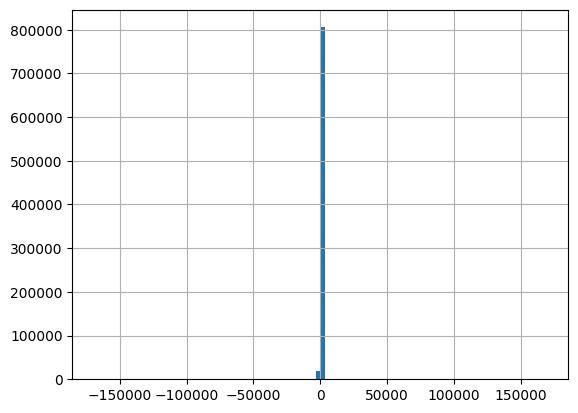

In [24]:
df.Revenue.hist(bins=100)

In [25]:
df.Revenue.skew()

np.float64(-0.6055106760639487)

## Побудова когорт

### 1 Подія формування когорти

Перший і найважливіший крок у когортному аналізі — це **вибір події, за якою формується когорта**.
Це та подія, від якої ми починаємо відлік «життя» користувача в системі.

У загальному вигляді подією формування когорти може бути:

* реєстрація користувача,
* перша активність,
* перший платіж,
* перша покупка.

У задачах e-commerce нас цікавлять **реальні клієнти, які приносять гроші**, а не просто відвідувачі сайту.
Тому логічно визначати початок життя користувача не з моменту реєстрації і не з моменту візиту, а саме з моменту **першої покупки**.

Таким чином ми формуємо когорти за принципом:

> *Когорта — це всі клієнти, які здійснили свою першу покупку в одному і тому ж місяці.*

Наприклад:

* усі клієнти, які вперше купили в **січні 2025** → когорта `2025-01`,
* усі клієнти з першою покупкою в **лютому 2025** → когорта `2025-02`.

Такий підхід дозволяє:

* порівнювати, **як поводяться клієнти, залучені в різні періоди**;
* оцінювати **якість маркетингу в різні місяці**;
* аналізувати, **чи стали нові клієнти гіршими або кращими за старих**;
* коректно рахувати retention і LTV саме для платоспроможної аудиторії.

Фактично, ми відповідаємо на питання:

> *Як живуть клієнти, які почали платити в один і той самий період часу?*

І саме від цієї точки (першої покупки) далі будується весь когортний аналіз:
вік когорти, утримання, повторні покупки і накопичений дохід.

In [ ]:
df.columns.to_list()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country',
 'Revenue']

In [26]:
df.groupby('Customer ID')['InvoiceDate'].min()

,InvoiceDate
Customer ID,
12346,2009-12-14 08:34:00
12347,2010-10-31 14:20:00
12348,2010-09-27 14:59:00
12349,2009-12-04 12:49:00
12350,2011-02-02 16:01:00
...,...
18283,2010-02-19 17:16:00
18284,2010-10-04 11:33:00
18285,2010-02-17 10:24:00


In [ ]:
df.shape

(824364, 9)

In [27]:
df.groupby('Customer ID')['InvoiceDate'].transform('min')

,InvoiceDate
0,2009-12-01 07:45:00
1,2009-12-01 07:45:00
2,2009-12-01 07:45:00
3,2009-12-01 07:45:00
4,2009-12-01 07:45:00
...,...
1067366,2011-08-18 15:44:00
1067367,2011-08-18 15:44:00
1067368,2011-08-18 15:44:00
1067369,2011-08-18 15:44:00


In [28]:
df['CohortDate'] = df.groupby('Customer ID')['InvoiceDate'].transform('min')

`transform('min')` **по суті це повний аналог віконної функції в SQL**. У термінах SQL це було б:

```sql
MIN(InvoiceDate) OVER (PARTITION BY CustomerID)
```

In [29]:
df[df['Customer ID'] == 13085]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,CohortDate
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009-12-01 07:45:00
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12-01 07:45:00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12-01 07:45:00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009-12-01 07:45:00
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009-12-01 07:45:00
...,...,...,...,...,...,...,...,...,...,...
775536,558996,22617,BAKING SET SPACEBOY DESIGN,3,2011-07-05 12:11:00,4.95,13085,United Kingdom,14.85,2009-12-01 07:45:00
775537,558996,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-07-05 12:11:00,4.95,13085,United Kingdom,14.85,2009-12-01 07:45:00
775538,558996,20749,ASSORTED COLOUR MINI CASES,2,2011-07-05 12:11:00,7.95,13085,United Kingdom,15.90,2009-12-01 07:45:00
775539,558996,22193,RED DINER WALL CLOCK,2,2011-07-05 12:11:00,8.50,13085,United Kingdom,17.00,2009-12-01 07:45:00


### 2 Гранулярність

Після того як ми визначили подію формування когорти (перша покупка), наступне питання:

**у яких одиницях часу ми будемо аналізувати життя когорти?**

Це - **гранулярність** когортного аналізу.

В нашому випадку ми беремо:

* **місяць першої покупки** → місяць формування когорти
* **місяць будь-якої покупки** → місяць активності клієнта

Тобто ми працюємо з двома різними, але пов’язаними поняттями:

1. **Cohort Month** — місяць, у якому клієнт зробив першу покупку
2. **Event Month** — місяць, у якому клієнт зробив конкретну покупку

In [30]:
df['CohortMonth'] = df['CohortDate'].dt.to_period('M')
df[df['Customer ID'] == 13085]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,CohortDate,CohortMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009-12-01 07:45:00,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12-01 07:45:00,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12-01 07:45:00,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009-12-01 07:45:00,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009-12-01 07:45:00,2009-12
...,...,...,...,...,...,...,...,...,...,...,...
775536,558996,22617,BAKING SET SPACEBOY DESIGN,3,2011-07-05 12:11:00,4.95,13085,United Kingdom,14.85,2009-12-01 07:45:00,2009-12
775537,558996,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-07-05 12:11:00,4.95,13085,United Kingdom,14.85,2009-12-01 07:45:00,2009-12
775538,558996,20749,ASSORTED COLOUR MINI CASES,2,2011-07-05 12:11:00,7.95,13085,United Kingdom,15.90,2009-12-01 07:45:00,2009-12
775539,558996,22193,RED DINER WALL CLOCK,2,2011-07-05 12:11:00,8.50,13085,United Kingdom,17.00,2009-12-01 07:45:00,2009-12


In [31]:
df['EventMonth'] = df['InvoiceDate'].dt.to_period('M')
df[df['Customer ID'] == 13085]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,CohortDate,CohortMonth,EventMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009-12-01 07:45:00,2009-12,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12-01 07:45:00,2009-12,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12-01 07:45:00,2009-12,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009-12-01 07:45:00,2009-12,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009-12-01 07:45:00,2009-12,2009-12
...,...,...,...,...,...,...,...,...,...,...,...,...
775536,558996,22617,BAKING SET SPACEBOY DESIGN,3,2011-07-05 12:11:00,4.95,13085,United Kingdom,14.85,2009-12-01 07:45:00,2009-12,2011-07
775537,558996,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-07-05 12:11:00,4.95,13085,United Kingdom,14.85,2009-12-01 07:45:00,2009-12,2011-07
775538,558996,20749,ASSORTED COLOUR MINI CASES,2,2011-07-05 12:11:00,7.95,13085,United Kingdom,15.90,2009-12-01 07:45:00,2009-12,2011-07
775539,558996,22193,RED DINER WALL CLOCK,2,2011-07-05 12:11:00,8.50,13085,United Kingdom,17.00,2009-12-01 07:45:00,2009-12,2011-07


### 3 Вік когорти

In [34]:
df['CohortIndex'] = (df.EventMonth - df.CohortMonth).apply(lambda interval: interval.n)

In [35]:
df[df['Customer ID'] == 13085]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,CohortDate,CohortMonth,EventMonth,CohortIndex
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,2009-12-01 07:45:00,2009-12,2009-12,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12-01 07:45:00,2009-12,2009-12,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,2009-12-01 07:45:00,2009-12,2009-12,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,2009-12-01 07:45:00,2009-12,2009-12,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,2009-12-01 07:45:00,2009-12,2009-12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
775536,558996,22617,BAKING SET SPACEBOY DESIGN,3,2011-07-05 12:11:00,4.95,13085,United Kingdom,14.85,2009-12-01 07:45:00,2009-12,2011-07,19
775537,558996,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-07-05 12:11:00,4.95,13085,United Kingdom,14.85,2009-12-01 07:45:00,2009-12,2011-07,19
775538,558996,20749,ASSORTED COLOUR MINI CASES,2,2011-07-05 12:11:00,7.95,13085,United Kingdom,15.90,2009-12-01 07:45:00,2009-12,2011-07,19
775539,558996,22193,RED DINER WALL CLOCK,2,2011-07-05 12:11:00,8.50,13085,United Kingdom,17.00,2009-12-01 07:45:00,2009-12,2011-07,19


* 0 — місяць першої покупки
* 1 — через місяць
* 2 — через два і т.д.

In [36]:
tmp = df[df['Customer ID'] == 13085]
tmp.CohortIndex.unique()

array([ 0,  1, 10, 14, 16, 19])

## Retention-аналіз

### 1 Агрегація

In [37]:
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_data

,CohortMonth,CohortIndex,Customer ID
0,2009-12,0,1045
1,2009-12,1,392
2,2009-12,2,358
3,2009-12,3,447
4,2009-12,4,410
...,...,...,...
320,2011-10,1,74
321,2011-10,2,39
322,2011-11,0,192
323,2011-11,1,33


In [39]:
cohort_data[cohort_data['CohortMonth'] == '2009-12']

,CohortMonth,CohortIndex,Customer ID
0,2009-12,0,1045
1,2009-12,1,392
2,2009-12,2,358
3,2009-12,3,447
4,2009-12,4,410
5,2009-12,5,408
6,2009-12,6,408
7,2009-12,7,374
8,2009-12,8,355
9,2009-12,9,392


### 2 Pivot Table

In [40]:
cohort_pivot = cohort_data.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer ID')
cohort_pivot

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,1045.0,392.0,358.0,447.0,410.0,408.0,408.0,374.0,355.0,392.0,...,319.0,273.0,316.0,303.0,287.0,274.0,332.0,319.0,427.0,218.0
2010-01,394.0,86.0,119.0,120.0,110.0,115.0,105.0,91.0,114.0,134.0,...,60.0,86.0,74.0,69.0,73.0,93.0,73.0,88.0,29.0,NaN
2010-02,363.0,109.0,82.0,110.0,93.0,76.0,79.0,103.0,100.0,106.0,...,74.0,67.0,61.0,53.0,85.0,90.0,62.0,23.0,NaN,NaN
2010-03,436.0,95.0,113.0,103.0,100.0,87.0,105.0,130.0,126.0,50.0,...,74.0,76.0,69.0,74.0,89.0,93.0,33.0,NaN,NaN,NaN
2010-04,291.0,67.0,58.0,47.0,54.0,67.0,79.0,76.0,33.0,34.0,...,43.0,41.0,41.0,50.0,61.0,19.0,NaN,NaN,NaN,NaN
2010-05,254.0,49.0,45.0,49.0,48.0,66.0,56.0,33.0,17.0,22.0,...,33.0,36.0,42.0,40.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,269.0,58.0,53.0,55.0,62.0,76.0,35.0,25.0,22.0,32.0,...,33.0,37.0,55.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,183.0,38.0,37.0,52.0,55.0,28.0,21.0,28.0,26.0,22.0,...,32.0,45.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,158.0,39.0,50.0,51.0,29.0,21.0,16.0,22.0,23.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3 Retention

#### Крок 1. Визначаємо розмір кожної когорти

Ми беремо **перший стовпець (індекс 0)**.

Це:

* кількість користувачів у момент їх першої покупки,
* тобто **реальний розмір когорти на старті**.

In [41]:
column_1 = cohort_pivot.iloc[:, 0]

In [ ]:
column_1

,0
CohortMonth,
2009-12,955.0
2010-01,383.0
2010-02,374.0
2010-03,443.0
2010-04,294.0
2010-05,254.0
2010-06,270.0
2010-07,186.0
2010-08,162.0


#### Крок 2. Перетворюємо абсолютні числа в відсотки

Ми ділимо **кожен рядок** на відповідний розмір когорти.

Тобто математично:

$$
Retention_{i,j} = \frac{Users_{i,j}}{Users_{i,0}}
$$

де:

* `i` — когорта,
* `j` — вік когорти.

In [42]:
retention = cohort_pivot.divide(column_1, axis=0)
retention

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.375120,0.342584,0.427751,0.392344,0.390431,0.390431,0.357895,0.339713,0.375120,...,0.305263,0.261244,0.302392,0.289952,0.274641,0.262201,0.317703,0.305263,0.408612,0.208612
2010-01,1.0,0.218274,0.302030,0.304569,0.279188,0.291878,0.266497,0.230964,0.289340,0.340102,...,0.152284,0.218274,0.187817,0.175127,0.185279,0.236041,0.185279,0.223350,0.073604,NaN
2010-02,1.0,0.300275,0.225895,0.303030,0.256198,0.209366,0.217631,0.283747,0.275482,0.292011,...,0.203857,0.184573,0.168044,0.146006,0.234160,0.247934,0.170799,0.063361,NaN,NaN
2010-03,1.0,0.217890,0.259174,0.236239,0.229358,0.199541,0.240826,0.298165,0.288991,0.114679,...,0.169725,0.174312,0.158257,0.169725,0.204128,0.213303,0.075688,NaN,NaN,NaN
2010-04,1.0,0.230241,0.199313,0.161512,0.185567,0.230241,0.271478,0.261168,0.113402,0.116838,...,0.147766,0.140893,0.140893,0.171821,0.209622,0.065292,NaN,NaN,NaN,NaN
2010-05,1.0,0.192913,0.177165,0.192913,0.188976,0.259843,0.220472,0.129921,0.066929,0.086614,...,0.129921,0.141732,0.165354,0.157480,0.047244,NaN,NaN,NaN,NaN,NaN
2010-06,1.0,0.215613,0.197026,0.204461,0.230483,0.282528,0.130112,0.092937,0.081784,0.118959,...,0.122677,0.137546,0.204461,0.059480,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.207650,0.202186,0.284153,0.300546,0.153005,0.114754,0.153005,0.142077,0.120219,...,0.174863,0.245902,0.092896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.246835,0.316456,0.322785,0.183544,0.132911,0.101266,0.139241,0.145570,0.132911,...,0.202532,0.069620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
tmp = retention * 100

In [46]:
tmp = tmp.round(0)
tmp

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,38.0,34.0,43.0,39.0,39.0,39.0,36.0,34.0,38.0,...,31.0,26.0,30.0,29.0,27.0,26.0,32.0,31.0,41.0,21.0
2010-01,100.0,22.0,30.0,30.0,28.0,29.0,27.0,23.0,29.0,34.0,...,15.0,22.0,19.0,18.0,19.0,24.0,19.0,22.0,7.0,NaN
2010-02,100.0,30.0,23.0,30.0,26.0,21.0,22.0,28.0,28.0,29.0,...,20.0,18.0,17.0,15.0,23.0,25.0,17.0,6.0,NaN,NaN
2010-03,100.0,22.0,26.0,24.0,23.0,20.0,24.0,30.0,29.0,11.0,...,17.0,17.0,16.0,17.0,20.0,21.0,8.0,NaN,NaN,NaN
2010-04,100.0,23.0,20.0,16.0,19.0,23.0,27.0,26.0,11.0,12.0,...,15.0,14.0,14.0,17.0,21.0,7.0,NaN,NaN,NaN,NaN
2010-05,100.0,19.0,18.0,19.0,19.0,26.0,22.0,13.0,7.0,9.0,...,13.0,14.0,17.0,16.0,5.0,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,22.0,20.0,20.0,23.0,28.0,13.0,9.0,8.0,12.0,...,12.0,14.0,20.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,21.0,20.0,28.0,30.0,15.0,11.0,15.0,14.0,12.0,...,17.0,25.0,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,25.0,32.0,32.0,18.0,13.0,10.0,14.0,15.0,13.0,...,20.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
pd.set_option('display.float_format', lambda x: f'{x:.0f}')

In [53]:
tmp

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,100,38,34,43,39,39,39,36,34,38,...,31,26,30,29,27,26,32,31,41,21
2010-01,100,22,30,30,28,29,27,23,29,34,...,15,22,19,18,19,24,19,22,7,NaN
2010-02,100,30,23,30,26,21,22,28,28,29,...,20,18,17,15,23,25,17,6,NaN,NaN
2010-03,100,22,26,24,23,20,24,30,29,11,...,17,17,16,17,20,21,8,NaN,NaN,NaN
2010-04,100,23,20,16,19,23,27,26,11,12,...,15,14,14,17,21,7,NaN,NaN,NaN,NaN
2010-05,100,19,18,19,19,26,22,13,7,9,...,13,14,17,16,5,NaN,NaN,NaN,NaN,NaN
2010-06,100,22,20,20,23,28,13,9,8,12,...,12,14,20,6,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100,21,20,28,30,15,11,15,14,12,...,17,25,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100,25,32,32,18,13,10,14,15,13,...,20,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Ми зробили **найголовнішу операцію в когортному аналізі**:

перетворили *кількість користувачів* у *ймовірність утримання користувача*.

Тепер кожна клітинка означає:

> «Яка частка клієнтів з цієї когорти
> повернулася через N місяців після першої покупки».

## Візуалізація

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

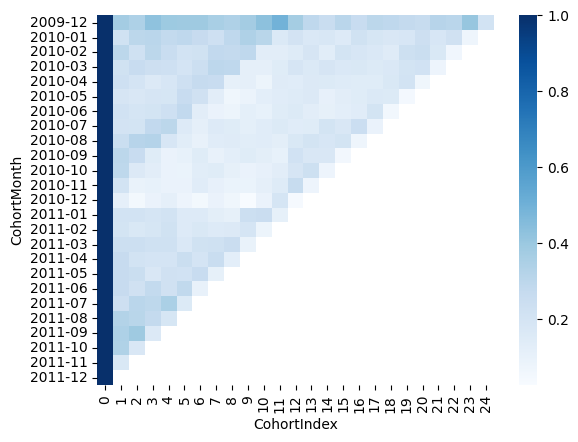

In [55]:
sns.heatmap(retention, annot=False, cmap='Blues')
plt.show()

Отримуємо **теплову карту утримання**.

### Загальна картина

Що ми бачимо одразу:

* У всіх когорт **різкий спад уже після 1–2 місяця**
* Далі retention повільно, але стабільно зменшується
* Жодної когорти з “плато” або зростанням

Це означає:

> Бізнес має **короткий життєвий цикл клієнта**.
> Більшість клієнтів роблять 1–2 покупки і зникають.

---

### Поведінка типової когорти

Візьмемо умовно будь-яку середню когорту (наприклад 2010-06):

* Місяць 0: 100%
* Місяць 1: ~30–35%
* Місяць 2: ~20–25%
* Місяць 3+: <20%

Інтерпретація:

> Лише **кожен третій** клієнт повертається на другий місяць.
> Через 3–4 місяці залишається **кожен п’ятий або менше**.

Це типовий патерн **одноразових покупок**.

---

### Чи є покращення з часом? (найважливіше питання)

Дивимось на когорти зверху вниз (у часі):

* 2009–2010: retention трохи вищий
* 2011: retention помітно нижчий

Тобто:

> **Новіші когорти гірші за старі.**

Це дуже сильний бізнес-сигнал:

* або якість трафіку погіршилась
* або продукт став менш привабливим
* або маркетинг приводить «холодніших» клієнтів

Це **ознака деградації, а не росту**.


## Грошовий когортний аналіз (LTV)

### 1 Дохід по когортам

In [56]:
revenue_ltv = df.groupby(['CohortMonth', 'CohortIndex'])['Revenue'].sum().reset_index()

In [57]:
revenue_ltv[revenue_ltv['CohortMonth'] == '2009-12']

,CohortMonth,CohortIndex,Revenue
0,2009-12,0,663272
1,2009-12,1,381103
2,2009-12,2,294003
3,2009-12,3,386888
4,2009-12,4,304759
5,2009-12,5,291166
6,2009-12,6,308089
7,2009-12,7,316265
8,2009-12,8,335917
9,2009-12,9,372772


### 2 Кумулятивний LTV

In [58]:
ltv = revenue_ltv.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='Revenue')
ltv

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,663272,381103,294003,386888,304759,291166,308089,316265,335917,372772,...,256772,163873,281355,288823,252951,264802,386539,401336,460389,164782
2010-01,150850,37495,50786,55621,52353,56076,43417,43045,53144,73136,...,27535,41287,31825,43055,35640,52639,54339,46097,6407,NaN
2010-02,157902,29828,49944,47854,40480,36876,36668,45756,50846,53182,...,36586,28047,31174,23261,42273,42781,34742,10994,NaN,NaN
2010-03,168495,45622,45456,51677,44478,48932,58582,73206,67809,33124,...,29666,34406,46736,44051,52169,57530,15737,NaN,NaN,NaN
2010-04,104689,15935,18172,25833,20574,30880,31640,27327,13354,16998,...,19481,17109,17647,23228,25262,4367,NaN,NaN,NaN,NaN
2010-05,107160,14144,13600,12712,16270,30934,21973,13130,4493,7030,...,14334,23515,16579,15293,3299,NaN,NaN,NaN,NaN,NaN
2010-06,82821,12069,22331,24071,32141,46960,23516,17153,23809,27844,...,17835,37108,25358,4436,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,70248,7638,13527,23159,27604,15576,8507,10460,9659,9925,...,15483,21947,7048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,59440,13509,22846,22896,22296,5110,5294,7197,9704,9706,...,19763,5620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
ltv = revenue_ltv.pivot_table(
    index='CohortMonth',
    columns='CohortIndex',
    values='Revenue'
    ).cumsum(axis=1)
ltv

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,686654.160,1082079.731,1378881.863,1758536.353,2065422.173,2371376.063,2674233.623,2987736.353,3320235.193,3712871.213,...,6058840.735,6222185.036,6508805.076,6789098.706,7043668.856,7317994.376,7694907.467,8110873.707,8558875.137,8722766.357
2010-01,161893.491,201027.541,252147.801,309876.452,368736.812,429913.962,482021.762,530212.082,590816.022,665608.142,...,961635.652,1011574.482,1052545.932,1100357.442,1143070.682,1202303.192,1262267.632,1320982.652,1329808.512,NaN
2010-02,170434.884,203802.064,258688.364,312084.284,356108.824,395887.304,436050.494,487394.325,540432.625,595368.845,...,772397.135,802453.715,835861.935,861387.585,906894.125,952940.665,991638.835,1002786.405,NaN,NaN
2010-03,235467.061,285474.751,337444.021,402234.811,452687.971,508753.091,574370.261,655999.231,732824.441,768069.221,...,987867.931,1030722.171,1080756.571,1128226.811,1185733.741,1248360.181,1265668.421,NaN,NaN,NaN
2010-04,125100.731,144137.081,164851.321,194969.171,217279.131,248125.701,283367.101,316142.101,331479.301,349177.221,...,456150.911,474025.301,493448.961,525621.891,555701.091,560644.061,NaN,NaN,NaN,NaN
2010-05,110770.000,124444.350,138625.950,151479.130,168340.440,199666.300,223070.790,236845.280,242728.550,249966.760,...,333010.320,355234.000,372973.150,388911.140,392333.780,NaN,NaN,NaN,NaN,NaN
2010-06,131827.950,147945.310,170551.610,196453.510,231517.280,280079.410,305545.000,322824.230,346705.200,375241.420,...,538755.660,577242.560,605345.370,609807.790,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,75377.760,83774.660,97584.050,122591.700,151515.000,167352.270,176471.070,186992.470,197419.050,207415.420,...,287413.490,310110.610,317293.910,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,61158.840,74988.740,98137.500,121682.320,144087.870,149520.460,154827.590,162115.610,171979.040,181818.250,...,265180.310,270800.420,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
long_var = ltv.reset_index().melt(
    id_vars='CohortMonth',
    var_name='CohortIndex',
    value_name='LTV')

In [61]:
long_var

,CohortMonth,CohortIndex,LTV
0,2009-12,0,663272
1,2010-01,0,150850
2,2010-02,0,157902
3,2010-03,0,168495
4,2010-04,0,104689
...,...,...,...
620,2011-08,24,NaN
621,2011-09,24,NaN
622,2011-10,24,NaN
623,2011-11,24,NaN


In [62]:
fig = px.line(
    long_var,
    x='CohortIndex',
    y='LTV',
    color='CohortMonth')
fig.show()

## Як інтерпретувати результати

### Retention

Дивимося:

* як швидко падають рядки
* чи стабільні нові когорти
* де різкі “обриви”

Типові висновки:

* Якщо retention падає з кожною новою когортою → проблема продукту або якості трафіку.
* Якщо старі когорти тримаються краще → продукт деградує.

---

### LTV

Дивимося:

* на форму кривих
* де плато
* які когорти ростуть довше

Бізнес-інтерпретація:

* когорти з вищим LTV = **якісні клієнти**
* якщо LTV виходить на плато на 2-3 місяці → життєвий цикл клієнта короткий
* якщо LTV росте 6-8 місяців → сильна лояльність